In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import datetime


from src.analytics.aws_function_logs import AWSFunctionLogs
from src.profiler.config_manager import ConfigManager
from src.profiler.explorer import Explorer
from src.profiler.cost_calculator import CostCalculator
from src.application.step_functions import StepFunctions

from src.modeling.function_performance_modeling import FunctionPerformanceModeling

In [2]:
# function_name = 'infer'
payload = "{\"para1\":1, \"para2\":[1,2,3,4,100], \"para3\":[1,100]}"
region_name = 'us-east-1'

memeory_bounds = (128, 3009)
memory_space_step = 64


for i in range(1, 9):
    function_name = f'A1_F{i}'
    p_model = FunctionPerformanceModeling(function_name=function_name, payload=payload)
    o_memory = p_model.get_optimal_memory()
    print(f'Optimal memory for {function_name} is {o_memory}')
    ConfigManager(function_name=function_name, boto_session=boto3.Session(region_name=region_name)).set_config(o_memory)
    del p_model

[]
[3047. 3092. 3064. 3108.]
[3047. 3092. 3064. 3108.  341.  357.  362.  356.]
Explored memories: [ 128  128  128  128 1089 1089 1089 1089 3008 3008 3008 3008]
Sample Count:  12
Max Sample Count:  20
Memories:  [ 128  128  128  128 1089 1089 1089 1089 3008 3008 3008 3008]
Duration:  [3047. 3092. 3064. 3108.  341.  357.  362.  356.  272.  285.  289.  286.]
Value and Threshold:  1.90174256113063 3
[3047. 3092. 3064. 3108.  341.  357.  362.  356.  272.  285.  289.  286.]
Sample Count:  16
Max Sample Count:  20
Memories:  [ 128  128  128  128  662  662  662  662 1089 1089 1089 1089 3008 3008
 3008 3008]
Duration:  [3047. 3092. 3064. 3108.  555.  579.  592.  619.  341.  357.  362.  356.
  272.  285.  289.  286.]
Value and Threshold:  2.1347653272690685 3
[3047. 3092. 3064. 3108.  555.  579.  592.  619.  341.  357.  362.  356.
  272.  285.  289.  286.]
Sample Count:  20
Max Sample Count:  20
Memories:  [ 128  128  128  128  662  662  662  662 1089 1089 1089 1089 1586 1586
 1586 1586 3008 300

In [3]:
explorer = Explorer(
    function_name=function_name,
    payload=payload,
    boto_session=boto3.Session(region_name=region_name),
    memory_space_step=memory_space_step,
    max_invocations=5
)

explorer.explore_all_memories(num_of_invocations=5)

Processing: 100%|██████████ [Elapsed: 09:52 | Remaining: 00:00]


In [17]:
df = AWSFunctionLogs(
    boto_session=boto3.Session(region_name=region_name),
    function_name=function_name,
).get_logs_df(start_time=int((datetime.datetime.utcnow() - datetime.timedelta(days=1)).timestamp()), end_time=int(datetime.datetime.utcnow()))

df.to_csv(f'{function_name}_logs.csv')

In [18]:
config_manager = ConfigManager(function_name=function_name, boto_session=boto3.Session(region_name=region_name))

print(config_manager.get_config())

FunctionConfig(memory_mb=1296, timeout_s=10)


In [19]:
cost_calculator = CostCalculator(
    function_name=function_name,
)

In [20]:
df = pd.read_csv(f'{function_name}_logs.csv')

In [21]:
logs = df[df['Init Duration'].isna()]

logs = logs.groupby('Memory Size').agg({
    'Duration': 'mean',
}).reset_index()

if 'Duration' in logs.columns and 'Memory Size' in logs.columns:
    # Calculate the cost using .loc to avoid SettingWithCopyWarning
    logs.loc[:, 'Cost'] = logs.apply(
        lambda row: cost_calculator.calculate_cost(
            memory_mb=row['Memory Size'],
            duration_ms=row['Duration']
        ),
        axis=1
    )


In [28]:
# memory_space = np.arange(memeory_bounds[0], memeory_bounds[1] + 1, memory_space_step)

memory_space = np.arange(memeory_bounds[0], memeory_bounds[1] + 1)

logs = logs[logs['Memory Size'].isin(memory_space)]
# logs['Modeled Duration'] = logs['Memory Size'].apply(duration_per_memory)
# logs['Modeled Cost'] = logs.apply(
#     lambda row: cost_calculator.calculate_cost(
#         memory_mb=row['Memory Size'],
#         duration_ms=row['Modeled Duration']
#     ),
#     axis=1
# )

modeled_duration = []
modeled_cost = []

for memory in memory_space:
    t = duration_per_memory(memory)
    modeled_duration.append(t)
    modeled_cost.append(cost_calculator.calculate_cost(memory_mb=memory, duration_ms=t))

modeled_duration = np.array(modeled_duration)
modeled_cost = np.array(modeled_cost)

# mape_duration = (np.abs(logs['Duration'] - logs['Modeled Duration']) / logs['Duration']).mean() * 100
# mape_cost = (np.abs(logs['Cost'] - logs['Modeled Cost']) / logs['Cost']).mean() * 100

In [29]:
logs

,Memory Size,Duration,Cost
0,128.0,402727.923626,8.392183e-04
1,192.0,104.508000,5.281257e-07
2,256.0,59.642000,4.500005e-07
3,320.0,71.012000,5.750007e-07
4,384.0,48.078000,5.062506e-07
5,448.0,57.054000,6.229175e-07
6,512.0,43.212222,5.666674e-07
7,576.0,37.346000,5.562507e-07
8,640.0,38.648000,6.062508e-07
9,704.0,44.506000,7.156260e-07


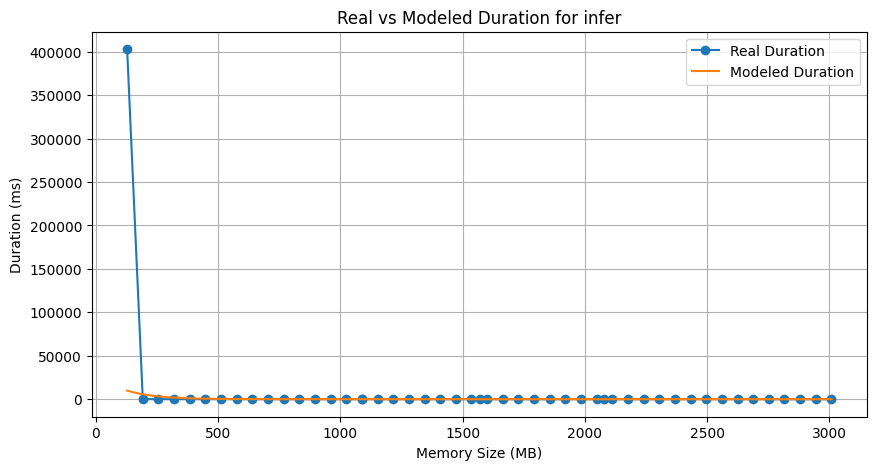

In [30]:
# Real vs Modeled Duration
plt.figure(figsize=(10, 5))
plt.plot(logs['Memory Size'], logs['Duration'], label='Real Duration', marker='o')
# plt.plot(logs['Memory Size'], logs['Modeled Duration'], label='Modeled Duration', marker='o')
plt.plot(memory_space, modeled_duration, label='Modeled Duration')
plt.xlabel('Memory Size (MB)')
plt.ylabel('Duration (ms)')
plt.title(f'Real vs Modeled Duration for {function_name}')
plt.legend()
plt.grid()

plt.show()

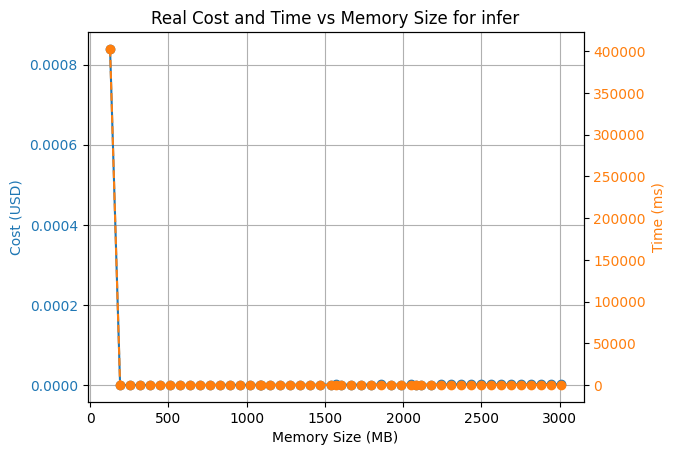

In [31]:
# Create figure and axis objects
fig, ax1 = plt.subplots()

# Plot Cost on the primary y-axis
ax1.set_xlabel('Memory Size (MB)')
ax1.set_ylabel('Cost (USD)', color='tab:blue')
ax1.plot(logs['Memory Size'], logs['Cost'], color='tab:blue', marker='o', label='Cost')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for Time
ax2 = ax1.twinx()
ax2.set_ylabel('Time (ms)', color='tab:orange')
ax2.plot(logs['Memory Size'], logs['Duration'], color='tab:orange', marker='o', linestyle='--', label='Time')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Add a title and grid
plt.title('Real Cost and Time vs Memory Size for ' + function_name)
ax1.grid(True)

# Show plot
plt.show()

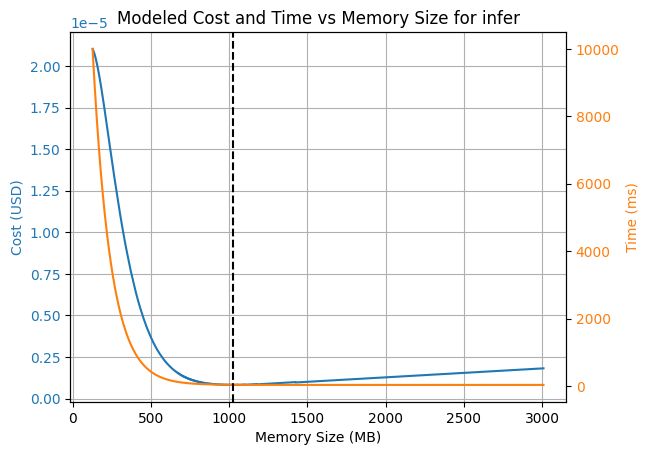

In [32]:
# Create figure and axis objects
fig, ax1 = plt.subplots()


# Plot Cost on the primary y-axis
ax1.set_xlabel('Memory Size (MB)')
ax1.set_ylabel('Cost (USD)', color='tab:blue')
# ax1.plot(logs['Memory Size'], logs['Modeled Cost'], color='tab:blue', marker='o', label='Cost')
ax1.plot(memory_space, modeled_cost, color='tab:blue', label='Cost')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for Time
ax2 = ax1.twinx()
ax2.set_ylabel('Time (ms)', color='tab:orange')
# ax2.plot(logs['Memory Size'], logs['Modeled Duration'], color='tab:red', marker='o', linestyle='--', label='Time')
ax2.plot(memory_space, modeled_duration, color='tab:orange', label='Time')
ax2.axvline(x=optimal_memory, color='black', linestyle='--', label='Optimal Memory')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Add a title and grid
plt.title('Modeled Cost and Time vs Memory Size for ' + function_name)
ax1.grid(True)

# Show plot
plt.show()

In [27]:
print(f'MAPE Duration: {mape_duration}')
print(f'MAPE Cost: {mape_cost}')

NameError: name 'mape_duration' is not defined